In [1]:
from dataset import load_dfs, download_zip
from zipfile import ZipFile
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pandas as pd

In [2]:
path = download_zip()

with ZipFile(path) as archive:
    print(archive.namelist())

['AMZN_2012-06-21_34200000_57600000_orderbook_10.csv', 'AMZN_2012-06-21_34200000_57600000_message_10.csv', 'LOBSTER_SampleFiles_ReadMe.txt']


In [3]:
books, messages = load_dfs()

In [4]:
midnight = datetime.fromisoformat('2012-06-21T00:00-04:00')

In [5]:
times = []
for offset in messages['time']:
    times.append(midnight + timedelta(seconds=offset))

In [6]:
books.index = pd.DatetimeIndex(times)

Text(0.5, 1.0, 'Level 10 Order Book Spread')

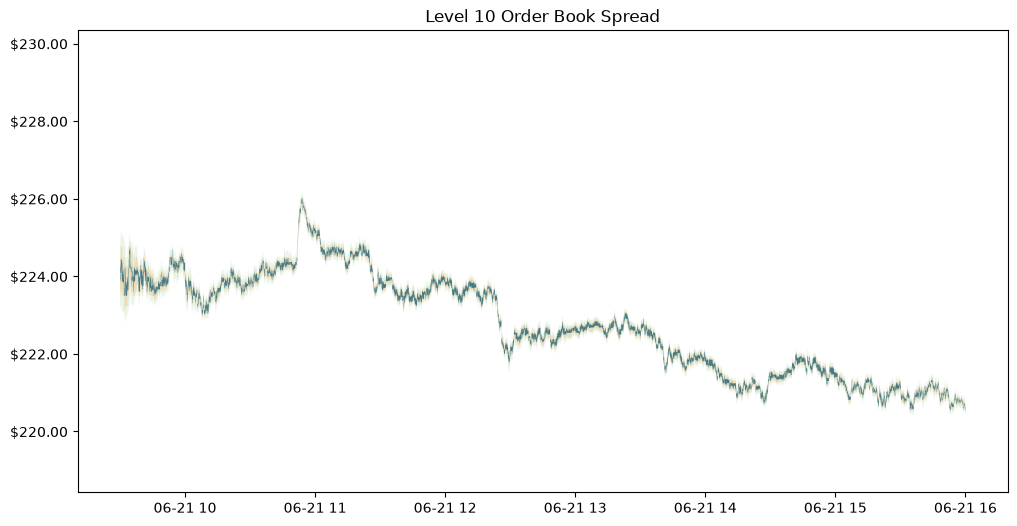

In [7]:
dollar_scale = 1e4

fig = plt.figure(figsize=(12, 6))
ax = fig.subplots()
ax.yaxis.set_major_formatter('${x:1.2f}')
plt.fill_between(books.index, books['BIDp1'] / dollar_scale, books['ASKp1'] / dollar_scale)
plt.fill_between(books.index, books['BIDp5'] / dollar_scale, books['ASKp5'] / dollar_scale, alpha=0.2)
plt.fill_between(books.index, books['BIDp10'] / dollar_scale, books['ASKp10'] / dollar_scale, alpha=0.1)
plt.title('Level 10 Order Book Spread')

## Order Book Structure

In order to make a model that respects some of these constraints, it's worth investigating the structure of the order book, and how we might want to constrain our model to fit that structure.

Let's begin by investigating the relationship of the difference between prices within one book.

In [8]:
from itertools import pairwise
import numpy as np

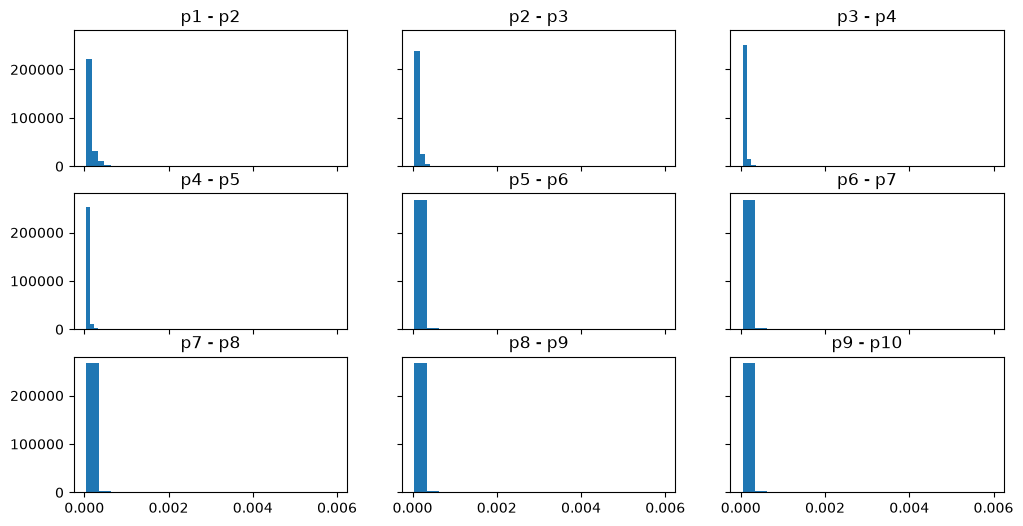

In [9]:
fig = plt.figure(figsize=(12, 6))
fig.subplots(3, 3, sharex=True, sharey=True)

for i, j in pairwise(range(1, 11)):
    diffs = np.log(books[f'BIDp{i}']) - np.log(books[f'BIDp{j}'])
    plt.subplot(3, 3, i)
    plt.title(f'p{i} - p{j}')
    plt.hist(diffs, bins=20)

Superficially, these differences in bid prices fall within a narrow band, but also are clearly are not constant. They are all non-negative which is useful information to us. Perhaps they follow a gamma distribution?

Let's look at the same plot for asks instead of bids. We'll negate the difference just so they follow a similar pattern to read.

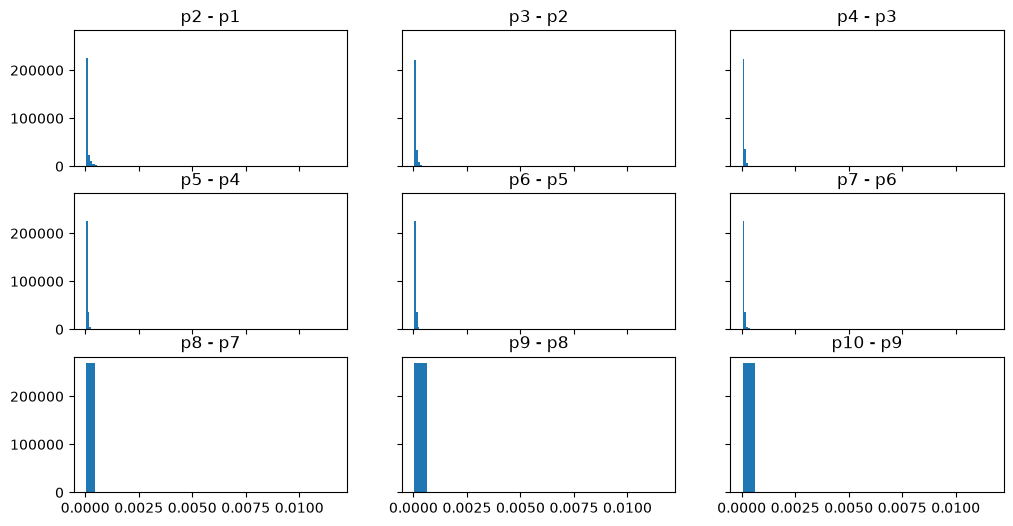

In [10]:
fig = plt.figure(figsize=(12, 6))
fig.subplots(3, 3, sharex=True, sharey=True)

for i, j in pairwise(range(1, 11)):
    diffs = np.log(books[f'ASKp{j}']) - np.log(books[f'ASKp{i}'])
    plt.subplot(3, 3, i)
    plt.title(f'p{j} - p{i}')
    plt.hist(diffs, bins=20)

The trend is very similar as above, but especially for the better asks, the distributions of those gaps is obviously narrower.

Another helpful piece of information in the relationship between these things would be the confusion matrix of the correlation between all these gaps.

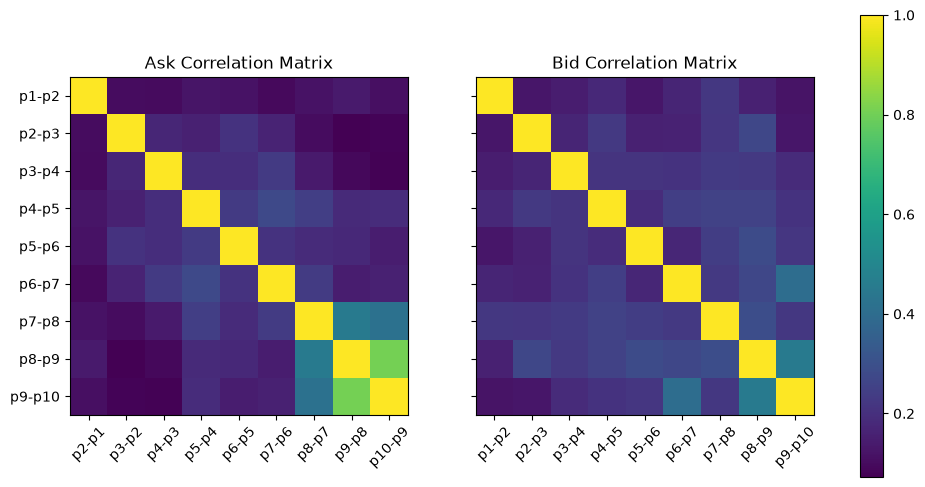

In [11]:
ask_diffs = []
ask_names = []
bid_diffs = []
bid_names = []

for i, j in pairwise(range(1, 11)):
    ask_diffs.append(np.log(books[f'ASKp{j}']) - np.log(books[f'ASKp{i}']))
    ask_names.append(f'p{j}-p{i}')
    bid_diffs.append(np.log(books[f'BIDp{i}']) - np.log(books[f'BIDp{j}']))
    bid_names.append(f'p{i}-p{j}')

import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors

asks_data = pd.concat(ask_diffs, axis=1, keys=ask_names)
bids_data = pd.concat(bid_diffs, axis=1, keys=bid_names)

fig = plt.figure(figsize=(12, 6))

norm = mcolors.Normalize(vmin=np.min(np.stack((asks_data.corr(), bids_data.corr()))), vmax=np.max(np.stack((asks_data.corr(), bids_data.corr()))))
colorizer = mcolorizer.Colorizer(norm=norm)

(ax1, ax2) = fig.subplots(1, 2, sharey=True)
ax1.set_title('Ask Correlation Matrix')
im = ax1.imshow(asks_data.corr(), colorizer=colorizer)
ax1.set_xticks(ticks=np.arange(0, 9), labels=ask_names, rotation=45)
ax1.set_yticks(ticks=np.arange(0, 9), labels=ask_names)

ax2.set_title('Bid Correlation Matrix')
ax2.imshow(bids_data.corr(), colorizer=colorizer)
ax2.set_xticks(ticks=np.arange(0, 9), labels=bid_names, rotation=45)
ax2.set_yticks(ticks=np.arange(0, 9), labels=bid_names)
fig.colorbar(im, ax=[ax1, ax2], location="right")

For the most part, we can see that differences between one gap in the ask/bid list are mostly decorrelated to differences in the other. Except somewhat further down the book, the p8/9 gap seems to have some correlation with p9/10, having a correlation as high as ~0.8 for asks. This is hard to ignore since the order book is moving around as we saw in the spread graph earlier.

We can have a look at the scatter plot of the p8/9 and p9/10 variables and see if this correlation is meaningful in any way.

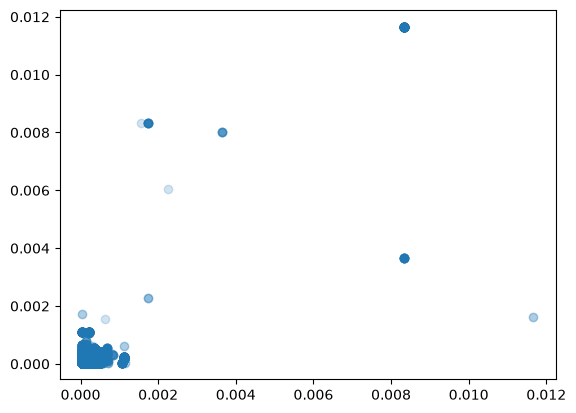

In [12]:
plt.scatter(ask_diffs[7], ask_diffs[8], alpha=0.2)

This has a notable presence of outliers that are likely contributing to our high correlation. We can exclude those and try our correlation again.

Correlation before outlier exclusion: 0.8065633762498007
Correlation after outlier exclusion: 0.1722130860940566


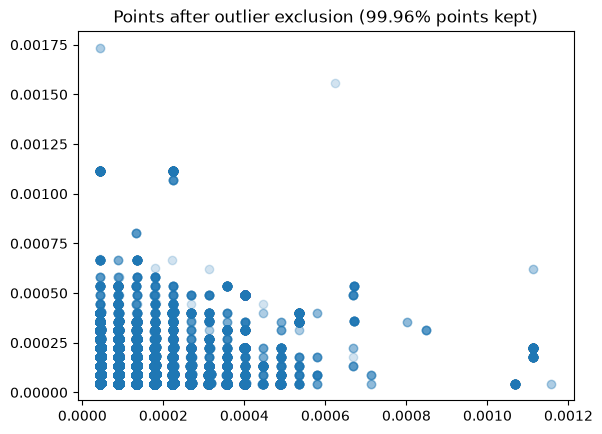

In [13]:
print('Correlation before outlier exclusion:', np.corrcoef(ask_diffs[7], ask_diffs[8])[0][1])

keep = (ask_diffs[7] <= 0.002) & (ask_diffs[8] <= 0.002)
kept_7 = np.zeros(np.sum(keep).item())
kept_8 = np.zeros(np.sum(keep).item())

kept_len = 0
for p7, p8, should_keep in zip(ask_diffs[7], ask_diffs[8], keep):
    if not should_keep: continue
    kept_7[kept_len] = p7
    kept_8[kept_len] = p8
    kept_len += 1

plt.title(f'Points after outlier exclusion ({keep.mean() * 100:1.2f}% points kept)')
plt.scatter(kept_7, kept_8, alpha=0.2)
print('Correlation after outlier exclusion:', np.corrcoef(kept_7, kept_8)[0][1])


We can have a look at some of the other higher-correlation squares and see if a similar effect explains them too.

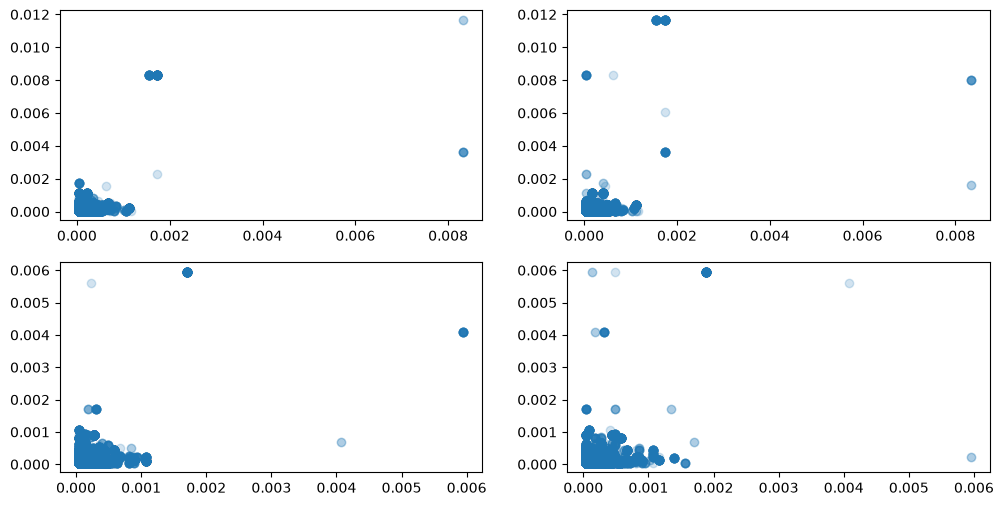

In [14]:
pairs = [(ask_diffs[6], ask_diffs[7]), (ask_diffs[6], ask_diffs[8]), (bid_diffs[7], bid_diffs[8]), (bid_diffs[5], bid_diffs[8])]

plt.figure(figsize=(12, 6))
for i, pair in enumerate(pairs):
    plt.subplot(2, 2, i + 1)
    plt.scatter(*pair, alpha=0.2)

Now we can look at some examples with low correlation and see if there are still these outliers.

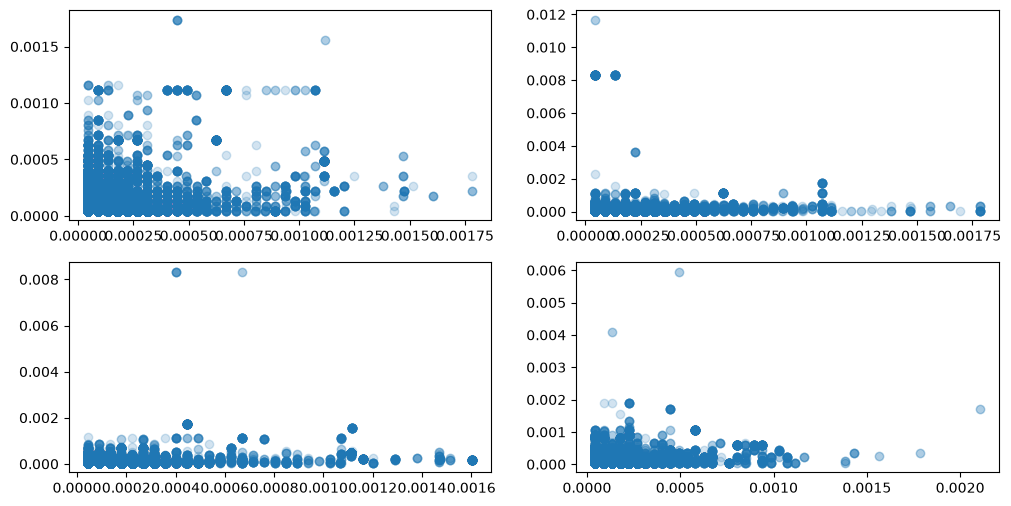

In [15]:
pairs = [(ask_diffs[2], ask_diffs[5]), (ask_diffs[1], ask_diffs[7]), (ask_diffs[3], ask_diffs[6]), (bid_diffs[2], bid_diffs[6])]

plt.figure(figsize=(12, 6))
for i, pair in enumerate(pairs):
    plt.subplot(2, 2, i + 1)
    plt.scatter(*pair, alpha=0.2)

Looking at the scale of these plots vs the previous ones, we can be sure that the outliers are causing high correlations, but that gaps from one price to the next are largely decorrelated.

### Outlier analysis

Let's have a look at one of these (repeated) outliers to see what it's structure is and why we're observing this behaviour.

In [16]:
select = (0.008 <= ask_diffs[7]) * (ask_diffs[7] < 0.010) * (0.002 <= ask_diffs[8]) * (ask_diffs[8] <= 0.006)
select.to_frame()[select].index

DatetimeIndex(['2012-06-21 09:30:00.538955-04:00',
               '2012-06-21 09:30:00.542125-04:00',
               '2012-06-21 09:30:00.542385-04:00',
               '2012-06-21 09:30:00.552352-04:00',
               '2012-06-21 09:30:00.552475-04:00',
               '2012-06-21 09:30:00.553434-04:00',
               '2012-06-21 09:30:00.553558-04:00',
               '2012-06-21 09:30:00.553743-04:00',
               '2012-06-21 09:30:00.567773-04:00',
               '2012-06-21 09:30:00.567937-04:00',
               '2012-06-21 09:30:00.567937-04:00',
               '2012-06-21 09:30:00.568240-04:00',
               '2012-06-21 09:30:00.569492-04:00',
               '2012-06-21 09:30:00.570714-04:00',
               '2012-06-21 09:30:00.571376-04:00',
               '2012-06-21 09:30:00.574401-04:00',
               '2012-06-21 09:30:00.630943-04:00'],
              dtype='datetime64[us, UTC-04:00]', freq=None)

It looks like all these repeated points are coming from a very narrow period of time. Inspecting more of these outliers, we see a similar phenomenon, and not only that but these points are also from the same second in time, 09:30 which is market open.

In [17]:
select = (0.008 <= ask_diffs[7]) * (ask_diffs[7] < 0.010) * (0.010 <= ask_diffs[8]) * (ask_diffs[8] <= 0.012)
select.to_frame()[select].index

DatetimeIndex(['2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:3

In [18]:
select = (0.000 <= ask_diffs[7]) * (ask_diffs[7] < 0.002) * (0.008 <= ask_diffs[8]) * (ask_diffs[8] <= 0.010)
select.to_frame()[select].index

DatetimeIndex(['2012-06-21 09:30:00.189608-04:00',
               '2012-06-21 09:30:00.391413-04:00',
               '2012-06-21 09:30:00.393040-04:00',
               '2012-06-21 09:30:00.394405-04:00',
               '2012-06-21 09:30:00.398457-04:00',
               '2012-06-21 09:30:00.398596-04:00',
               '2012-06-21 09:30:00.400329-04:00',
               '2012-06-21 09:30:00.401529-04:00',
               '2012-06-21 09:30:00.401529-04:00',
               '2012-06-21 09:30:00.401924-04:00',
               '2012-06-21 09:30:00.403006-04:00',
               '2012-06-21 09:30:00.631354-04:00',
               '2012-06-21 09:30:00.703012-04:00'],
              dtype='datetime64[us, UTC-04:00]', freq=None)

Let's see what the outlier gaps' time spread looks like for some other price gaps.

In [19]:
select = (0.001 <= bid_diffs[5]) * (bid_diffs[5] < 0.002) * (0.005 <= bid_diffs[8]) * (bid_diffs[8] <= 0.006)
select.to_frame()[select].index

DatetimeIndex(['2012-06-21 09:30:00.393040-04:00',
               '2012-06-21 09:30:00.393481-04:00',
               '2012-06-21 09:30:00.394405-04:00',
               '2012-06-21 09:30:00.398457-04:00',
               '2012-06-21 09:30:00.398596-04:00',
               '2012-06-21 09:30:00.400329-04:00',
               '2012-06-21 09:30:00.401529-04:00',
               '2012-06-21 09:30:00.401529-04:00',
               '2012-06-21 09:30:00.401924-04:00',
               '2012-06-21 09:30:00.403006-04:00',
               '2012-06-21 09:30:00.403006-04:00',
               '2012-06-21 09:30:00.403006-04:00',
               '2012-06-21 09:30:00.403006-04:00',
               '2012-06-21 09:30:00.407877-04:00',
               '2012-06-21 09:30:00.407877-04:00',
               '2012-06-21 09:30:00.407877-04:00',
               '2012-06-21 09:30:00.407877-04:00',
               '2012-06-21 09:30:00.411053-04:00',
               '2012-06-21 09:30:00.411053-04:00',
               '2012-06-21 09:3

It looks like some of the points further away from the best ask/bid get 'stuck' on the second of market open. We'll make note of the fact that the order book does this when training some models on it.

## Bid/Ask Gap Spread

Let's have a look at the distribution of that bid/ask gap throughout the day.

Text(0.5, 1.0, 'Log Gap Distribution')

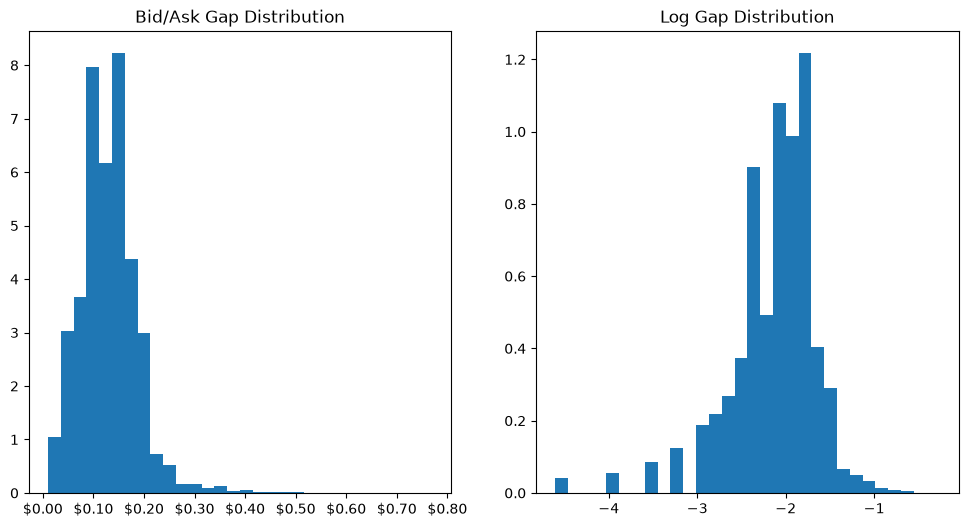

In [23]:
bid_ask_gaps = books['ASKp1'] - books['BIDp1']
bid_ask_gaps /= dollar_scale

fig = plt.figure(figsize=(12, 6))
ax1, ax2 = fig.subplots(1, 2)
ax1.hist(bid_ask_gaps, density=True, bins=30)
ax1.set_title('Bid/Ask Gap Distribution')
ax1.xaxis.set_major_formatter('${x:1.2f}')
ax2.hist(np.log(bid_ask_gaps), density=True, bins=30)
ax2.set_title('Log Gap Distribution')

As we would expect, it's strictly positive, but it also follows a distribution that looks similar to a Gamma distribution. We'll keep this in mind when evaluating the model's output structure.